2)  Create an academic performance dataset and perform data cleaning techniques such as handling null values, detecting outliers, and applying suitable data transformations for better analysis and visualization.( Data Wrangling I) 

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# # 1. Creating the Dataset
data = {
    'Student_Id' : [1, 2, 3, 4, 5, 6, 7, 8], 
    'Name' : ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Henry'], 
    'Math_Score' : [85, 90, np.nan, 88, 92, 300, 85, 89], 
    'Reading_Score' : [70, 72, 75, 68, 71, 69, 70, 500], 
    'Attendance' : [95, 80, 85, np.nan, 90, 88, 92, 85]
}

In [24]:
df = pd.DataFrame(data)

print("Step 1: Original Data with Issues")
display(df)

Step 1: Original Data with Issues


,Student_ID,Math_Score,Science_Score,Reading_Score,Age
0,1,85.0,80.0,70,20
1,2,90.0,82.0,72,21
2,3,NaN,78.0,75,19
3,4,70.0,95.0,68,20
4,5,88.0,2.0,74,22
5,6,150.0,88.0,80,-5
6,7,65.0,84.0,77,20
7,8,80.0,NaN,82,21
8,9,75.0,90.0,79,22
9,10,NaN,85.0,81,20


In [25]:
# --- Task 1: Handling Missing Values & Inconsistencies ---
# Fix logical inconsistency: Age cannot be negative
df.loc[df['Age'] <= 0, 'Age'] = np.nan

In [26]:
# Fill missing values using the Median (standard practice for skewed data)
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].median())
df['Science_Score'] = df['Science_Score'].fillna(df['Science_Score'].median())
df['Age'] = df['Age'].fillna(df['Age'].median())

In [27]:
# --- Task 2: Handling Outliers (IQR Method) ---
# We calculate the bounds for Math_Score
Q1 = df['Math_Score'].quantile(0.25)
Q3 = df['Math_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [28]:
# Capping: Replace outliers with the upper/lower boundary values
df['Math_Score'] = np.clip(df['Math_Score'], lower_bound, upper_bound)

In [29]:
# --- Task 3: Data Transformation ---
# Purpose: Reducing skewness using Log Transformation
# We use log1p (log(1+x)) to handle potential zeros gracefully
df['Log_Science'] = np.log1p(df['Science_Score'])

In [30]:
print("\nStep 2: Cleaned and Transformed Data")
display(df)


Step 2: Cleaned and Transformed Data


,Student_ID,Math_Score,Science_Score,Reading_Score,Age,Log_Science
0,1,85.00,80.0,70,20.0,4.394449
1,2,90.00,82.0,72,21.0,4.418841
2,3,82.50,78.0,75,19.0,4.369448
3,4,70.00,95.0,68,20.0,4.564348
4,5,88.00,2.0,74,22.0,1.098612
5,6,103.75,88.0,80,20.0,4.488636
6,7,65.00,84.0,77,20.0,4.442651
7,8,80.00,84.0,82,21.0,4.442651
8,9,75.00,90.0,79,22.0,4.510860
9,10,82.50,85.0,81,20.0,4.454347


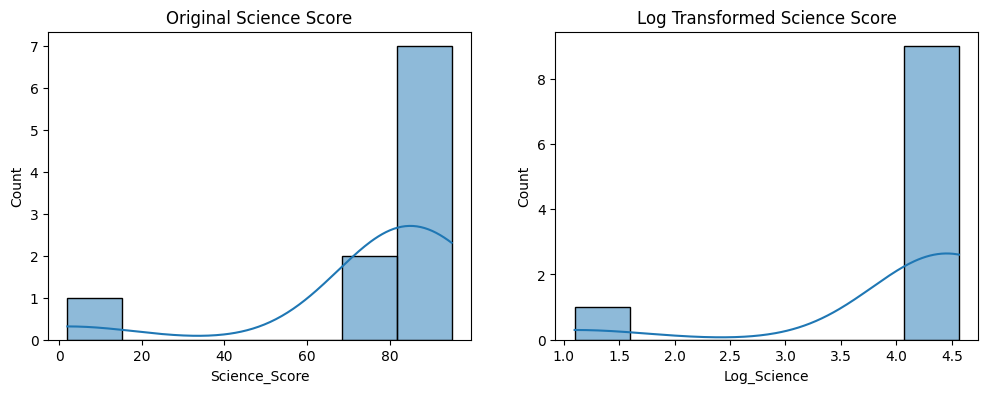

In [31]:
# Visualizing the distribution change (Optional but great for Jupyter)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Science_Score'], kde=True, ax=ax1).set_title('Original Science Score')
sns.histplot(df['Log_Science'], kde=True, ax=ax2).set_title('Log Transformed Science Score')
plt.show()